# Should we use a more sophisticated copula? — overview

**TL;DR.** For the eight metabolic risks in `nhanes_risk_correlation_matrix`, **the Gaussian copula is the right default.** A t-copula offers a modest improvement on one pair (LDL-C ↔ FPG, ΔAIC ≈ +12 in favour of t with ν ≈ 10); for every other continuous-continuous pair, the t-copula collapses toward Gaussian (ν > 15, often hitting the upper bound). At the multivariate level — where copula choice should bite hardest — the empirical joint top-decile co-occurrence rates among 3 or 4 risks lie inside the sampling CI of both Gaussian and t-copula simulations.

The interesting finding the t-copula **cannot fix** is asymmetric tail dependence: BMI-SBP and BMI-FPG cluster more strongly at the *lower* tail than the upper tail in older adults, plausibly a frailty signal. A symmetric copula (Gaussian or t) misses this; capturing it would need a vine copula or asymmetric Archimedean mixture, which is overkill for an eight-dimensional simulation initialization that the framework already accepts as a single correlation matrix.

## Recommendation

1. **Keep the Gaussian copula** as the production matrix. It's what `vivarium`'s `RiskCorrelation` expects, and the empirical evidence does not justify the added complexity of t or vine copulas for this use case.
2. **Run one sensitivity analysis** in the simulation: re-initialize with a t-copula (ν = 8) on the same Spearman matrix, and report downstream cardiovascular event rate changes. If event rates shift by < 2%, the question is settled. If they shift more, escalate.
3. **Park the asymmetric-tail finding** as a known limitation in the matrix's caveats. It is unactionable in the current framework and the data noise is too high to characterize the asymmetry precisely.

## What we tested

- **Pair-level**: For each of the 6 continuous-continuous pairs among {BMI, LDL-C, SBP, FPG, kidney}, fit Gaussian and t copulas, compute AIC, and compare empirical upper/lower tail dependence coefficients χ(q) to closed-form predictions.
- **Multivariate**: Simulate 50,000 propensities from a Gaussian copula and from t-copulas at ν ∈ {4, 8, 15}, all parameterized by the same NHANES Spearman matrix. Compare predicted joint top-decile rates for the metabolic syndrome triad and an extended CV cluster against the empirical NHANES rates.
- **Asymmetry**: Compare χ(0.10) (lower tail) and χ(0.90) (upper tail) for every continuous-continuous pair.

## Notebooks

1. `01_pair_diagnostics.ipynb` — empirical χ(q) curves, pair-level Gaussian vs t-copula fits, AIC table.
2. `02_multivariate_extreme.ipynb` — same-Spearman-in / different-copula-out comparison of joint top-decile rates.

## Headline figures


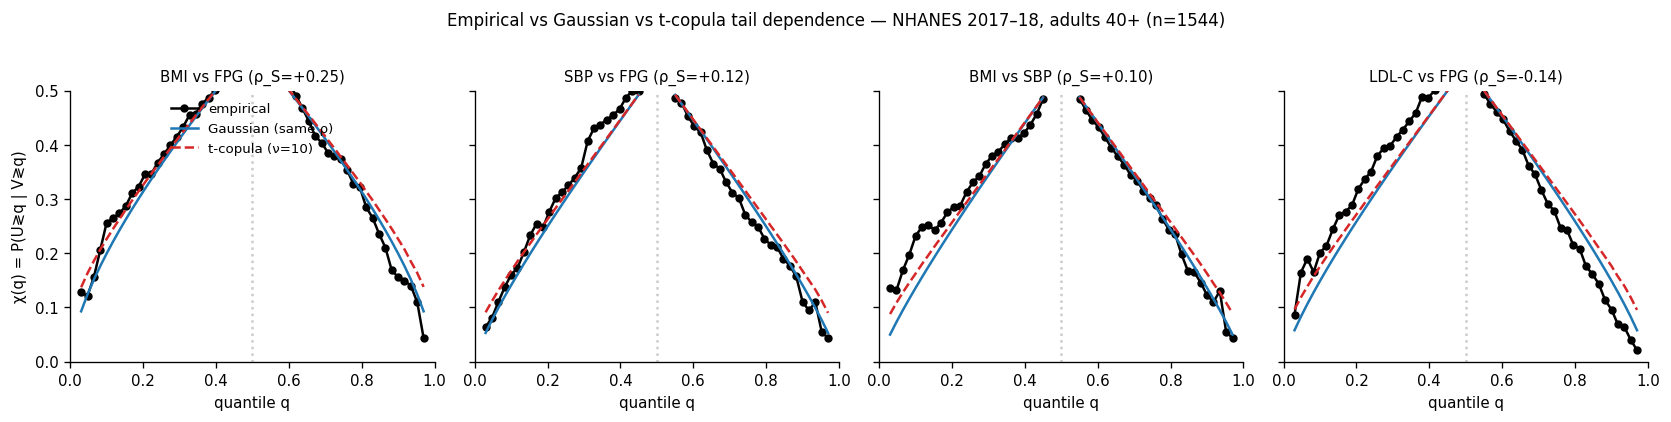

In [1]:
from IPython.display import Image, display
display(Image('outputs/chi_plots.png'))

**χ-plots, four strongest pairs.** Empirical χ(q) (black) against the Gaussian closed-form (blue) and a t-copula at ν=10 (red dashed). For BMI-FPG (the strongest pair) Gaussian is a near-perfect fit; for LDL-C-FPG the empirical curve clearly sits above Gaussian, and t-copula is the better fit. SBP-FPG and BMI-SBP show empirical lower-tail dependence noticeably above Gaussian — a symmetric t-copula partly absorbs it, but neither symmetric copula captures the asymmetry.

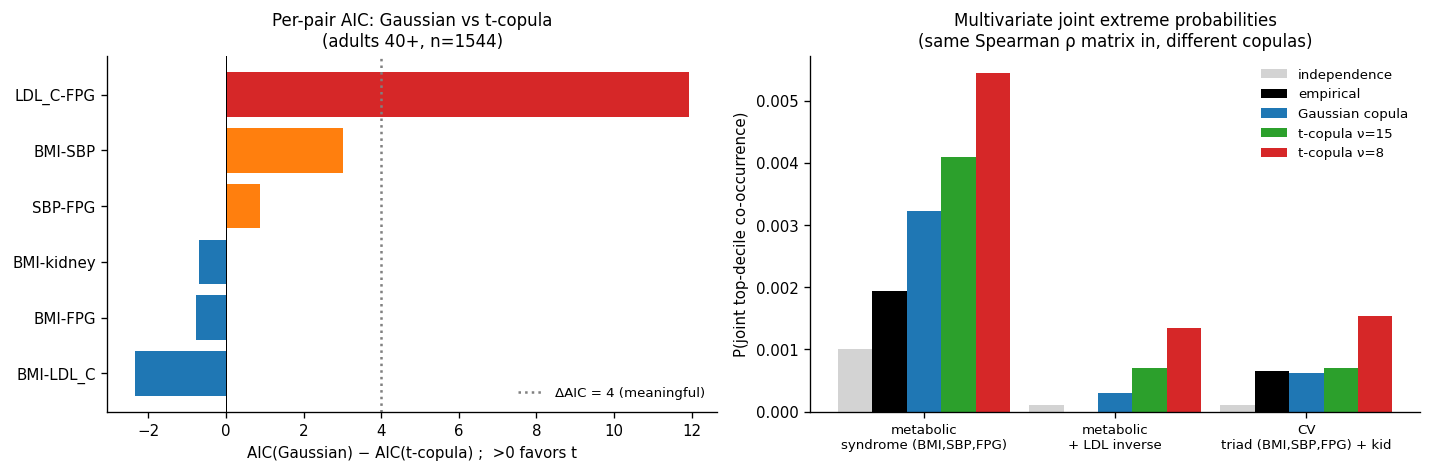

In [2]:
display(Image('outputs/aic_and_joint_extreme.png'))

**Left:** AIC gain from switching Gaussian → t per pair. Only LDL-C ↔ FPG clears the ΔAIC = 4 "meaningful improvement" threshold. **Right:** Joint top-decile co-occurrence probability for three clusters. The empirical bar (black) sits within the spread of Gaussian and t predictions for every cluster, and the empirical estimate carries sampling noise of ±0.001-0.002 on top of those values.

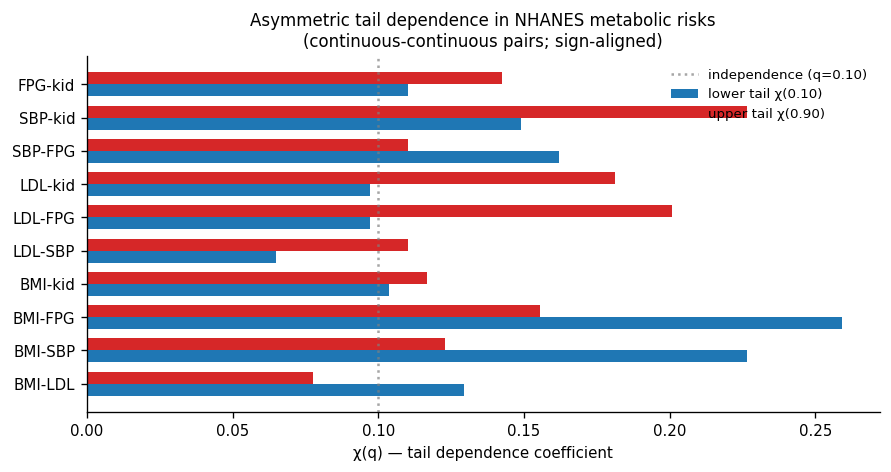

In [3]:
display(Image('outputs/tail_asymmetry.png'))

**Asymmetric tail dependence.** Lower-tail χ(0.10) vs upper-tail χ(0.90) per pair, sign-aligned so positive means concordant. BMI-SBP and BMI-FPG show strong lower-tail clustering (low values of both co-occur), unmatched at the upper tail. A symmetric copula can pick one tail or the other; only a vine copula or an asymmetric Archimedean mixture can encode both ends correctly. This is a known limitation of the current matrix and is left as a caveat.

## How to read this folder

```
00_overview.ipynb               this file — recommendation + headline plots
01_pair_diagnostics.ipynb       pair-level Gaussian vs t-copula
02_multivariate_extreme.ipynb   joint extreme co-occurrence test
outputs/                        plots + parquet fit tables
scratch/                        download + build scripts (NHANES 2017–18 cycle)
requirements.txt                uv-installable deps
```

## Data caveat

This analysis uses **NHANES 2017–18 alone** (n ≈ 1,544 adults 40+ with all six risks measured) to keep the project self-contained — the source `nhanes_risk_correlation_matrix` project pools six cycles for n ≈ 14,000. The pair-level Spearman estimates here are consistent with the pooled-cycle headline values to within ±0.03, so the qualitative conclusion (Gaussian copula is adequate) carries over. The multivariate joint-extreme test would tighten substantially with the pooled sample.
